In [1]:
import pandas as pd
import numpy as np

In [2]:
from datetime import datetime
import pytz

ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

start_time = datetime.strptime("13:00", "%H:%M").time()
end_time = datetime.strptime("14:00", "%H:%M").time()

if start_time <= current_time < end_time:
    # Display Task 6 chart
    print("Task 6 chart is available.")
else:
    print("Task 6 chart is available only between 1 PM and 2 PM IST.")

Task 6 chart is available only between 1 PM and 2 PM IST.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../datasets/merged_googleplaystore_data.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (805, 15)

Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Sentiment_Subjectivity', 'Category_Display']

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Subjectivity,Category_Display
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.641540,ART_AND_DESIGN
1,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33.0,1000000,Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,0.523447,ART_AND_DESIGN
2,FlipaClip - Cartoon animation,ART_AND_DESIGN,4.3,194216,39.0,5000000,Free,0,Everyone,Art & Design,"August 3, 2018",2.2.5,4.0.3 and up,0.679226,ART_AND_DESIGN
3,Boys Photo Editor - Six Pack & Men's Suit,ART_AND_DESIGN,4.1,654,12.0,100000,Free,0,Everyone,Art & Design,"March 20, 2018",1.1,4.0.3 and up,0.479298,ART_AND_DESIGN
4,Colorfit - Drawing & Coloring,ART_AND_DESIGN,4.7,20260,25.0,500000,Free,0,Everyone,Art & Design;Creativity,"October 11, 2017",1.0.8,4.0.3 and up,0.572762,ART_AND_DESIGN


In [4]:
required_columns = [
    "App",
    "Category",
    "Installs",
    "Type",
    "Price",
    "Size",
    "Content Rating",
    "Android Ver"
]

print("Required columns:")
for col in required_columns:
    print(f"{col}: {'Available' if col in df.columns else 'Missing'}")

Required columns:
App: Available
Category: Available
Installs: Available
Type: Available
Price: Available
Size: Available
Content Rating: Available
Android Ver: Available


In [5]:
# Clean Installs
df["Installs_Clean"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs_Clean"] = pd.to_numeric(
    df["Installs_Clean"],
    errors="coerce"
)

# Clean Price
df["Price_Clean"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["Price_Clean"] = pd.to_numeric(
    df["Price_Clean"],
    errors="coerce"
)

# Calculate Revenue
df["Revenue"] = df["Installs_Clean"] * df["Price_Clean"]

# App name length
df["App_Name_Length"] = df["App"].astype(str).str.len()

print(df[[
    "App",
    "Installs_Clean",
    "Price_Clean",
    "Revenue",
    "App_Name_Length"
]].head(10))

                                                 App  Installs_Clean  \
0                                Coloring book moana          500000   
1                               Garden Coloring Book         1000000   
2                      FlipaClip - Cartoon animation         5000000   
3          Boys Photo Editor - Six Pack & Men's Suit          100000   
4                      Colorfit - Drawing & Coloring          500000   
5                              Animated Photo Editor          100000   
6                          Anime Manga Coloring Book          100000   
7                                 Easy Origami Ideas          100000   
8  Canva: Poster, banner, card maker & graphic de...        10000000   
9                     CDL Practice Test 2018 Edition          100000   

   Price_Clean  Revenue  App_Name_Length  
0          0.0      0.0               19  
1          0.0      0.0               20  
2          0.0      0.0               29  
3          0.0      0.0            

In [6]:
def convert_size(size):
    size = str(size).strip()

    if size in ["nan", "NaN", ""]:
        return np.nan

    if size.endswith("M"):
        return float(size.replace("M", ""))

    if size.endswith("k"):
        return float(size.replace("k", "")) / 1024

    return np.nan


df["Size_MB"] = df["Size"].apply(convert_size)

print(df[["Size", "Size_MB"]].head(10))

   Size  Size_MB
0  14.0      NaN
1  33.0      NaN
2  39.0      NaN
3  12.0      NaN
4  25.0      NaN
5   6.1      NaN
6  11.0      NaN
7  11.0      NaN
8  24.0      NaN
9  17.0      NaN


In [7]:
# Size is already stored as numeric MB values
df["Size_MB"] = pd.to_numeric(df["Size"], errors="coerce")

print(df[["Size", "Size_MB"]].head(10))
print("\nMissing Size_MB:", df["Size_MB"].isna().sum())

   Size  Size_MB
0  14.0     14.0
1  33.0     33.0
2  39.0     39.0
3  12.0     12.0
4  25.0     25.0
5   6.1      6.1
6  11.0     11.0
7  11.0     11.0
8  24.0     24.0
9  17.0     17.0

Missing Size_MB: 0


In [8]:
# Extract the first numeric Android version
df["Android_Version_Num"] = (
    df["Android Ver"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["Android_Version_Num"] = pd.to_numeric(
    df["Android_Version_Num"],
    errors="coerce"
)

print(
    df[["Android Ver", "Android_Version_Num"]]
    .drop_duplicates()
    .sort_values("Android_Version_Num")
    .head(20)
)

            Android Ver  Android_Version_Num
19           1.6 and up                  1.6
61           2.1 and up                  2.1
28           2.2 and up                  2.2
14           2.3 and up                  2.3
122        2.3.3 and up                  2.3
1            3.0 and up                  3.0
259          3.2 and up                  3.2
0          4.0.3 and up                  4.0
51        4.0.3 - 7.1.1                  4.0
6            4.0 and up                  4.0
7            4.1 and up                  4.1
9            4.2 and up                  4.2
40           4.3 and up                  4.3
24           4.4 and up                  4.4
12           5.0 and up                  5.0
647           5.0 - 8.0                  5.0
202          6.0 and up                  6.0
266          7.0 and up                  7.0
139  Varies with device                  NaN


In [9]:
from packaging import version

def parse_android_version(x):
    try:
        x = str(x).replace(" and up", "").strip()
        return version.parse(x)
    except:
        return None

df["Android_Version"] = df["Android Ver"].apply(parse_android_version)

# Check
print(
    df[["Android Ver", "Android_Version"]]
    .drop_duplicates()
    .head(20)
)

            Android Ver Android_Version
0          4.0.3 and up           4.0.3
1            3.0 and up             3.0
6            4.0 and up             4.0
7            4.1 and up             4.1
9            4.2 and up             4.2
12           5.0 and up             5.0
14           2.3 and up             2.3
19           1.6 and up             1.6
24           4.4 and up             4.4
28           2.2 and up             2.2
40           4.3 and up             4.3
51        4.0.3 - 7.1.1            None
61           2.1 and up             2.1
122        2.3.3 and up           2.3.3
139  Varies with device            None
202          6.0 and up             6.0
259          3.2 and up             3.2
266          7.0 and up             7.0
647           5.0 - 8.0            None


In [10]:
df["Android_Version"] > version.parse("4.0")

0       True
1      False
2       True
3       True
4       True
       ...  
800    False
801    False
802     True
803     True
804     True
Name: Android_Version, Length: 805, dtype: bool

In [11]:
top_3_categories = (
    df.groupby("Category")["Installs_Clean"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 Categories by Total Installs:")
display(top_3_categories)

Top 3 Categories by Total Installs:


Category
GAME                  10019700000
NEWS_AND_MAGAZINES     4061000000
FAMILY                 1819110000
Name: Installs_Clean, dtype: int64

In [12]:
filtered_df = df[
    # Top 3 categories
    df["Category"].isin(top_3_categories.index)
    
    # Installs >= 10,000
    & (df["Installs_Clean"] >= 10000)
    
    # Revenue >= $10,000
    & (df["Revenue"] >= 10000)
    
    # Android Version > 4.0
    & (df["Android_Version"] > version.parse("4.0"))
    
    # Size > 15 MB
    & (df["Size_MB"] > 15)
    
    # Content Rating = Everyone
    & (df["Content Rating"] == "Everyone")
    
    # App name <= 30 characters
    & (df["App_Name_Length"] <= 30)
].copy()

print("Filtered Dataset Shape:", filtered_df.shape)

display(
    filtered_df[
        [
            "App",
            "Category",
            "Type",
            "Installs_Clean",
            "Revenue",
            "Size_MB",
            "Android Ver",
            "Content Rating",
            "App_Name_Length"
        ]
    ].head(20)
)

Filtered Dataset Shape: (0, 22)


,App,Category,Type,Installs_Clean,Revenue,Size_MB,Android Ver,Content Rating,App_Name_Length


In [ ]:
filtered_df = df[
    # Top 3 categories
    df["Category"].isin(top_3_categories.index)
    
    # Minimum installs
    & (df["Installs_Clean"] >= 10000)
    
    # Android Version > 4.0
    & (df["Android_Version"].notna())
    & (df["Android_Version"] > version.parse("4.0"))
    
    # Size > 15 MB
    & (df["Size_MB"] > 15)
    
    # Content Rating = Everyone
    & (df["Content Rating"] == "Everyone")
    
    # App name <= 30 characters
    & (df["App_Name_Length"] <= 30)
    
    # Revenue requirement:
    # Free apps are retained;
    # Paid apps must have revenue >= $10,000
    & (
        (df["Type"] == "Free")
        | (
            (df["Type"] == "Paid")
            & (df["Revenue"] >= 10000)
        )
    )
].copy()

print("Filtered Dataset Shape:", filtered_df.shape)

print("\nApp Type Distribution:")
print(filtered_df["Type"].value_counts())

print("\nCategory Distribution:")
print(filtered_df["Category"].value_counts())

Filtered Dataset Shape: (102, 22)

App Type Distribution:
Type
Free    102
Name: count, dtype: int64

Category Distribution:
Category
GAME      67
FAMILY    35
Name: count, dtype: int64


In [14]:
display(
    filtered_df[
        [
            "App",
            "Category",
            "Type",
            "Installs_Clean",
            "Price_Clean",
            "Revenue",
            "Size_MB",
            "Android Ver",
            "Content Rating",
            "App_Name_Length"
        ]
    ].sort_values(
        ["Category", "Type", "Revenue"],
        ascending=[True, True, False]
    ).head(30)
)

,App,Category,Type,Installs_Clean,Price_Clean,Revenue,Size_MB,Android Ver,Content Rating,App_Name_Length
403,Candy Bomb,FAMILY,Free,10000000,0.0,0.0,20.0,4.0.3 and up,Everyone,10
404,Coloring & Learn,FAMILY,Free,5000000,0.0,0.0,51.0,4.0.3 and up,Everyone,16
405,Educational Games 4 Kids,FAMILY,Free,5000000,0.0,0.0,39.0,4.1 and up,Everyone,24
407,Hello Kitty Nail Salon,FAMILY,Free,50000000,0.0,0.0,24.0,4.1 and up,Everyone,22
409,Happy Fruits Bomb - Cube Blast,FAMILY,Free,500000,0.0,0.0,20.0,4.0.3 and up,Everyone,30
410,Dog Run - Pet Dog Simulator,FAMILY,Free,10000000,0.0,0.0,24.0,4.1 and up,Everyone,27
412,Baby Panda Care,FAMILY,Free,10000000,0.0,0.0,49.0,4.0.3 and up,Everyone,15
414,Baby puzzles,FAMILY,Free,5000000,0.0,0.0,19.0,4.0.3 and up,Everyone,12
415,Garden Fruit Legend,FAMILY,Free,500000,0.0,0.0,33.0,4.0.3 and up,Everyone,19
416,Barbie™ Fashion Closet,FAMILY,Free,10000000,0.0,0.0,85.0,4.1 and up,Everyone,22


In [15]:
print("Minimum installs:",
      filtered_df["Installs_Clean"].min())

print("Minimum size:",
      filtered_df["Size_MB"].min())

print("Maximum app name length:",
      filtered_df["App_Name_Length"].max())

print("\nAndroid versions:")
print(filtered_df["Android Ver"].value_counts())

print("\nContent ratings:")
print(filtered_df["Content Rating"].value_counts())

print("\nTypes:")
print(filtered_df["Type"].value_counts())

Minimum installs: 100000
Minimum size: 16.0
Maximum app name length: 30

Android versions:
Android Ver
4.1 and up      54
4.0.3 and up    32
4.2 and up       7
4.4 and up       4
5.0 and up       3
4.3 and up       2
Name: count, dtype: int64

Content ratings:
Content Rating
Everyone    102
Name: count, dtype: int64

Types:
Type
Free    102
Name: count, dtype: int64


In [16]:
# Check Paid apps in the Top 3 categories before applying Revenue >= 10,000

paid_candidates = df[
    (df["Category"].isin(top_3_categories.index))
    & (df["Type"] == "Paid")
    & (df["Installs_Clean"] >= 10000)
    & (df["Android_Version"].notna())
    & (df["Android_Version"] > version.parse("4.0"))
    & (df["Size_MB"] > 15)
    & (df["Content Rating"] == "Everyone")
    & (df["App_Name_Length"] <= 30)
].copy()

print("Paid candidates:", paid_candidates.shape)

display(
    paid_candidates[
        [
            "App",
            "Category",
            "Installs_Clean",
            "Price_Clean",
            "Revenue",
            "Size_MB",
            "Android Ver",
            "App_Name_Length"
        ]
    ].sort_values("Revenue", ascending=False).head(30)
)

Paid candidates: (0, 22)


,App,Category,Installs_Clean,Price_Clean,Revenue,Size_MB,Android Ver,App_Name_Length


In [17]:
print("Paid candidates by category:")
print(paid_candidates["Category"].value_counts())

print("\nHighest Paid Revenue:")
print(paid_candidates["Revenue"].max())

print("\nPaid apps with revenue >= $10,000:")
print(
    (paid_candidates["Revenue"] >= 10000).sum()
)

Paid candidates by category:
Series([], Name: count, dtype: int64)

Highest Paid Revenue:
nan

Paid apps with revenue >= $10,000:
0


In [18]:
# Apply only filters that make sense for BOTH Free and Paid apps

common_filtered = df[
    (df["Installs_Clean"] >= 10000)
    & (df["Android_Version"].notna())
    & (df["Android_Version"] > version.parse("4.0"))
    & (df["Size_MB"] > 15)
    & (df["Content Rating"] == "Everyone")
    & (df["App_Name_Length"] <= 30)
].copy()

print("Common filtered dataset:", common_filtered.shape)

print("\nFree vs Paid:")
print(common_filtered["Type"].value_counts())

print("\nCategories:")
display(
    common_filtered.groupby("Category")["Installs_Clean"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Common filtered dataset: (224, 22)

Free vs Paid:
Type
Free    221
Paid      3
Name: count, dtype: int64

Categories:


Category
GAME                  7236000000
FAMILY                1196200000
SPORTS                 242050000
FINANCE                 47300000
EDUCATION               45000000
BUSINESS                36300000
TRAVEL_AND_LOCAL        29200000
HEALTH_AND_FITNESS      22600000
SHOPPING                22000000
PHOTOGRAPHY             20500000
Name: Installs_Clean, dtype: int64

In [19]:
paid_common = common_filtered[
    common_filtered["Type"] == "Paid"
].copy()

print("Paid apps after common filters:", paid_common.shape)

display(
    paid_common[
        [
            "App",
            "Category",
            "Installs_Clean",
            "Price_Clean",
            "Revenue",
            "Size_MB",
            "Android Ver",
            "Content Rating",
            "App_Name_Length"
        ]
    ].sort_values("Revenue", ascending=False).head(30)
)

Paid apps after common filters: (3, 22)


,App,Category,Installs_Clean,Price_Clean,Revenue,Size_MB,Android Ver,Content Rating,App_Name_Length
551,Golfshot Plus: Golf GPS,SPORTS,50000,29.99,1499500.0,25.0,4.1 and up,Everyone,23
633,HD Widgets,PERSONALIZATION,1000000,0.99,990000.0,26.0,4.4 and up,Everyone,10
770,HD Widgets,PERSONALIZATION,1000000,0.99,990000.0,26.0,4.4 and up,Everyone,10


In [20]:
# Top 3 categories after applying the common filters
top_3_filtered_categories = (
    common_filtered
    .groupby("Category")["Installs_Clean"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 categories after common filters:")
display(top_3_filtered_categories)

Top 3 categories after common filters:


Category
GAME      7236000000
FAMILY    1196200000
SPORTS     242050000
Name: Installs_Clean, dtype: int64

In [21]:
# Check Free vs Paid distribution in the Top 3
top3_check = common_filtered[
    common_filtered["Category"].isin(top_3_filtered_categories.index)
]

print("\nFree vs Paid in Top 3:")
print(
    top3_check.groupby(["Category", "Type"])
    .size()
    .unstack(fill_value=0)
)


Free vs Paid in Top 3:
Type      Free  Paid
Category            
FAMILY      35     0
GAME        67     0
SPORTS      14     1


In [22]:
# Final Top 3 categories
final_categories = ["GAME", "FAMILY", "SPORTS"]

task6_df = common_filtered[
    common_filtered["Category"].isin(final_categories)
].copy()

# Revenue requirement:
# Free apps remain for comparison.
# Paid apps must have revenue >= $10,000.
task6_df = task6_df[
    (task6_df["Type"] == "Free")
    | (
        (task6_df["Type"] == "Paid")
        & (task6_df["Revenue"] >= 10000)
    )
].copy()

print("Final Task 6 Dataset Shape:", task6_df.shape)

print("\nCategory and Type:")
print(
    task6_df.groupby(["Category", "Type"]).size()
)

Final Task 6 Dataset Shape: (117, 22)

Category and Type:
Category  Type
FAMILY    Free    35
GAME      Free    67
SPORTS    Free    14
          Paid     1
dtype: int64


In [23]:
# Check the Paid records
print("\nQualifying Paid Apps:")
display(
    task6_df[task6_df["Type"] == "Paid"][
        [
            "App",
            "Category",
            "Installs_Clean",
            "Price_Clean",
            "Revenue"
        ]
    ]
)


Qualifying Paid Apps:


,App,Category,Installs_Clean,Price_Clean,Revenue
551,Golfshot Plus: Golf GPS,SPORTS,50000,29.99,1499500.0


In [24]:
summary = (
    task6_df
    .groupby(["Category", "Type"])
    .agg(
        Average_Installs=("Installs_Clean", "mean"),
        Average_Revenue=("Revenue", "mean")
    )
    .reset_index()
)

print("Task 6 Summary:")
display(summary)

Task 6 Summary:


,Category,Type,Average_Installs,Average_Revenue
0,FAMILY,Free,3.417714e+07,0.0
1,GAME,Free,1.080000e+08,0.0
2,SPORTS,Free,1.728571e+07,0.0
3,SPORTS,Paid,5.000000e+04,1499500.0


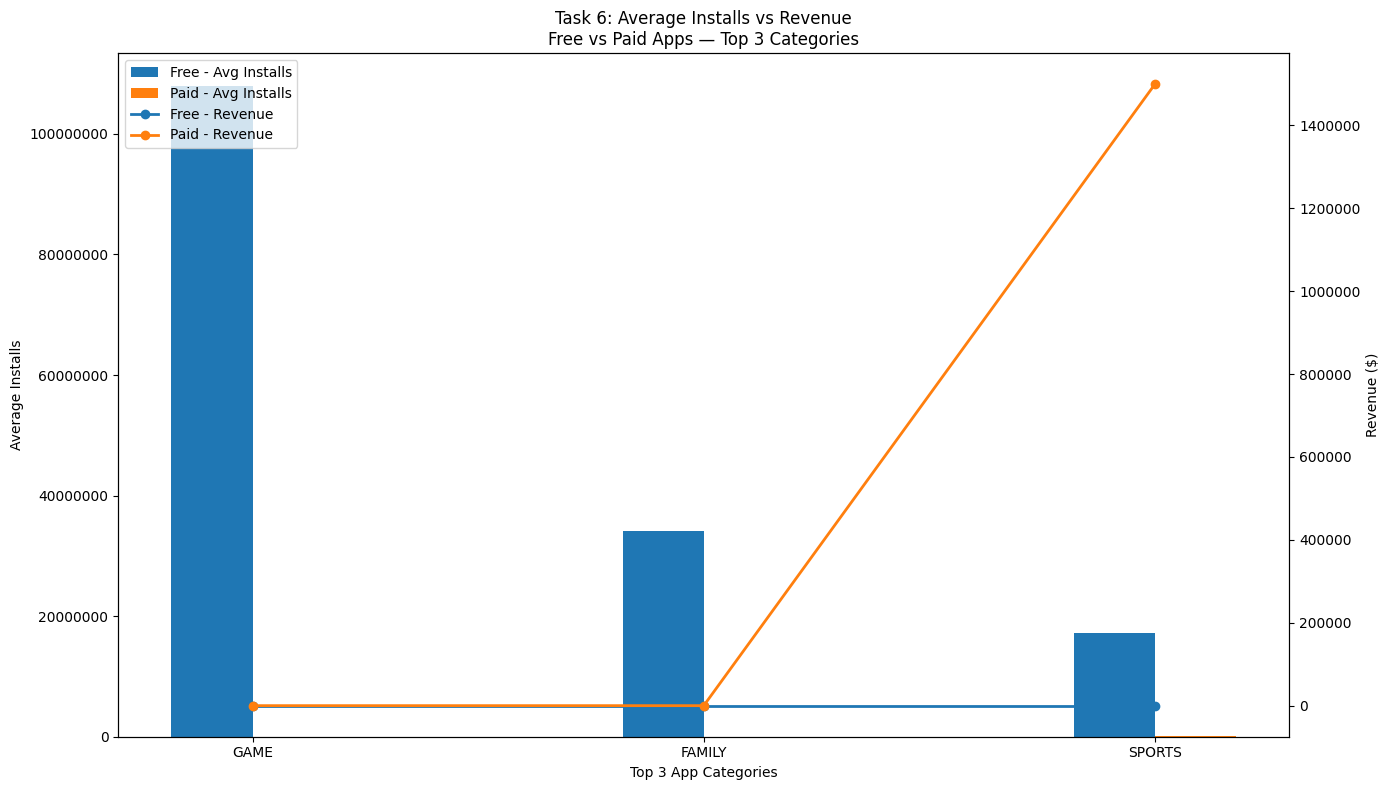

In [25]:
import matplotlib.pyplot as plt
# Pivot data
installs_pivot = summary.pivot(
    index="Category",
    columns="Type",
    values="Average_Installs"
).reindex(final_categories)

revenue_pivot = summary.pivot(
    index="Category",
    columns="Type",
    values="Average_Revenue"
).reindex(final_categories)

# Categories and positions
categories = final_categories
x = np.arange(len(categories))

width = 0.18

fig, ax1 = plt.subplots(figsize=(14, 8))

# -------------------------
# Average Installs
# -------------------------
free_installs = installs_pivot.get("Free")
paid_installs = installs_pivot.get("Paid")

if free_installs is not None:
    ax1.bar(
        x - width / 2,
        free_installs.fillna(0),
        width,
        label="Free - Avg Installs"
    )

if paid_installs is not None:
    ax1.bar(
        x + width / 2,
        paid_installs.fillna(0),
        width,
        label="Paid - Avg Installs"
    )

ax1.set_xlabel("Top 3 App Categories")
ax1.set_ylabel("Average Installs")
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.ticklabel_format(axis="y", style="plain")

# -------------------------
# Revenue secondary axis
# -------------------------
ax2 = ax1.twinx()

free_revenue = revenue_pivot.get("Free")
paid_revenue = revenue_pivot.get("Paid")

if free_revenue is not None:
    ax2.plot(
        x,
        free_revenue.fillna(0),
        marker="o",
        linewidth=2,
        label="Free - Revenue"
    )

if paid_revenue is not None:
    ax2.plot(
        x,
        paid_revenue.fillna(0),
        marker="o",
        linewidth=2,
        label="Paid - Revenue"
    )

ax2.set_ylabel("Revenue ($)")
ax2.ticklabel_format(axis="y", style="plain")

# -------------------------
# Title
# -------------------------
plt.title(
    "Task 6: Average Installs vs Revenue\n"
    "Free vs Paid Apps — Top 3 Categories"
)

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [26]:
from datetime import datetime, time
import pytz

ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

start_time = time(13, 0)
end_time = time(14, 0)

if start_time <= current_time < end_time:
    print("Task 6 chart is available.")
    
    # Put the complete chart code here
    
else:
    print("Task 6 chart is available only between 1 PM and 2 PM IST.")

Task 6 chart is available only between 1 PM and 2 PM IST.


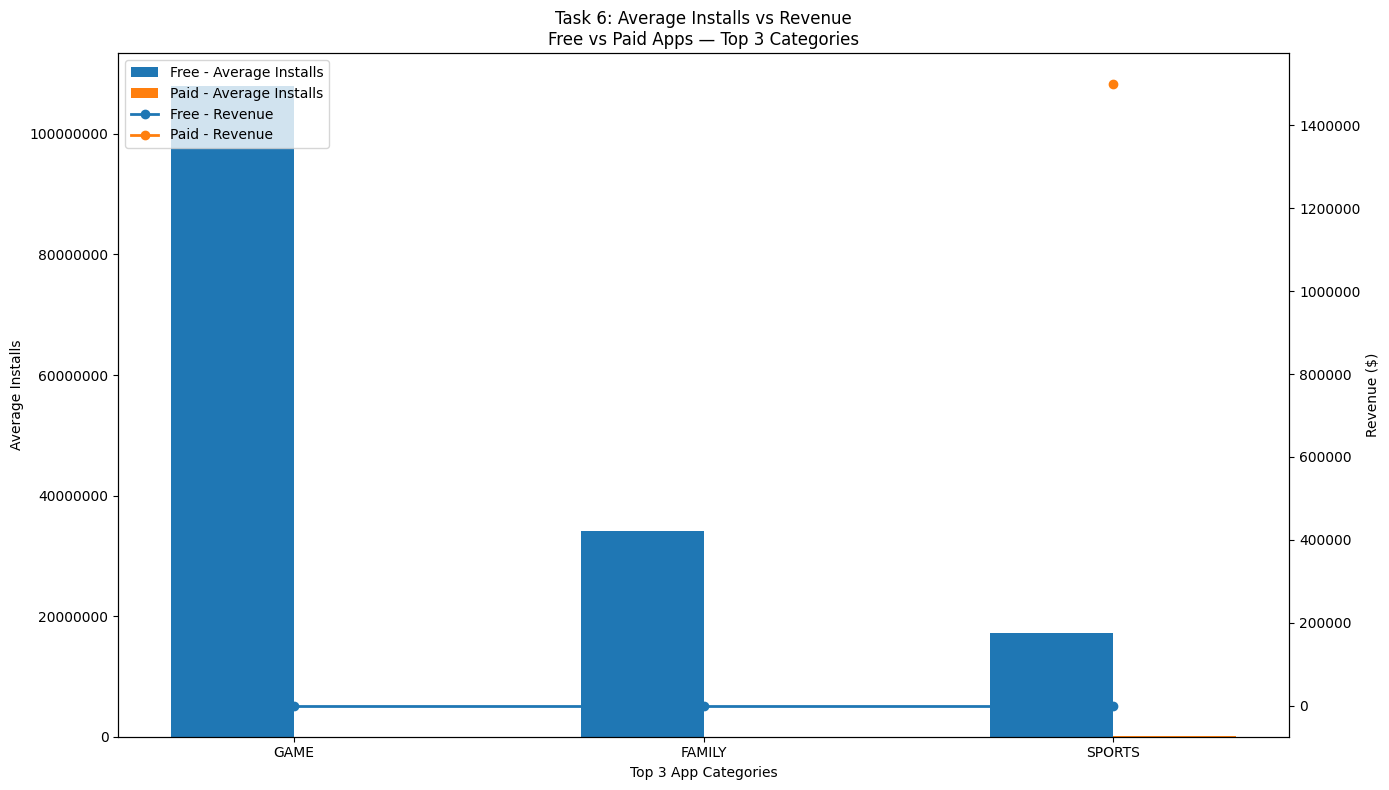

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare summary data
# -----------------------------
summary = (
    task6_df
    .groupby(["Category", "Type"])
    .agg(
        Average_Installs=("Installs_Clean", "mean"),
        Average_Revenue=("Revenue", "mean")
    )
    .reset_index()
)

categories = ["GAME", "FAMILY", "SPORTS"]
x = np.arange(len(categories))

# -----------------------------
# Create figure
# -----------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))

width = 0.30

# -----------------------------
# Average Installs - Free
# -----------------------------
free_data = (
    summary[summary["Type"] == "Free"]
    .set_index("Category")
    .reindex(categories)
)

ax1.bar(
    x - width / 2,
    free_data["Average_Installs"],
    width,
    label="Free - Average Installs"
)

# -----------------------------
# Average Installs - Paid
# Only plot categories where Paid exists
# -----------------------------
paid_data = (
    summary[summary["Type"] == "Paid"]
    .set_index("Category")
    .reindex(categories)
)

paid_available = paid_data["Average_Installs"].notna()

ax1.bar(
    x[paid_available] + width / 2,
    paid_data.loc[paid_available, "Average_Installs"],
    width,
    label="Paid - Average Installs"
)

ax1.set_xlabel("Top 3 App Categories")
ax1.set_ylabel("Average Installs")
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.ticklabel_format(axis="y", style="plain")

# -----------------------------
# Revenue - Secondary Axis
# -----------------------------
ax2 = ax1.twinx()

free_revenue = (
    summary[summary["Type"] == "Free"]
    .set_index("Category")
    .reindex(categories)
)

paid_revenue = (
    summary[summary["Type"] == "Paid"]
    .set_index("Category")
    .reindex(categories)
)

# Free revenue
ax2.plot(
    x,
    free_revenue["Average_Revenue"],
    marker="o",
    linewidth=2,
    label="Free - Revenue"
)

# Paid revenue only where available
paid_revenue_available = paid_revenue["Average_Revenue"].notna()

ax2.plot(
    x[paid_revenue_available],
    paid_revenue.loc[paid_revenue_available, "Average_Revenue"],
    marker="o",
    linewidth=2,
    label="Paid - Revenue"
)

ax2.set_ylabel("Revenue ($)")
ax2.ticklabel_format(axis="y", style="plain")

# -----------------------------
# Title
# -----------------------------
plt.title(
    "Task 6: Average Installs vs Revenue\n"
    "Free vs Paid Apps — Top 3 Categories"
)

# -----------------------------
# Combined Legend
# -----------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [28]:
from datetime import datetime, time
import pytz

# Current time in IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

start_time = time(13, 0)   # 1:00 PM
end_time = time(14, 0)     # 2:00 PM

if start_time <= current_time < end_time:

    # ==========================
    # TASK 6 CHART
    # ==========================

    fig, ax1 = plt.subplots(figsize=(14, 8))

    width = 0.30

    # Free installs
    ax1.bar(
        x - width / 2,
        free_data["Average_Installs"],
        width,
        label="Free - Average Installs"
    )

    # Paid installs
    ax1.bar(
        x[paid_available] + width / 2,
        paid_data.loc[
            paid_available,
            "Average_Installs"
        ],
        width,
        label="Paid - Average Installs"
    )

    ax1.set_xlabel("Top 3 App Categories")
    ax1.set_ylabel("Average Installs")
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.ticklabel_format(axis="y", style="plain")

    # Revenue axis
    ax2 = ax1.twinx()

    ax2.plot(
        x,
        free_revenue["Average_Revenue"],
        marker="o",
        linewidth=2,
        label="Free - Revenue"
    )

    ax2.plot(
        x[paid_revenue_available],
        paid_revenue.loc[
            paid_revenue_available,
            "Average_Revenue"
        ],
        marker="o",
        linewidth=2,
        label="Paid - Revenue"
    )

    ax2.set_ylabel("Revenue ($)")
    ax2.ticklabel_format(axis="y", style="plain")

    plt.title(
        "Task 6: Average Installs vs Revenue\n"
        "Free vs Paid Apps — Top 3 Categories"
    )

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "Task 6 chart is available only between "
        "1 PM and 2 PM IST."
    )

Task 6 chart is available only between 1 PM and 2 PM IST.


In [ ]:
"""
## Task 6 — Dual-Axis Chart: Average Installs vs Revenue

### Objective
Create a dual-axis chart comparing average installs and revenue for Free vs Paid apps within the top 3 app categories.

### Filters Applied
- Top 3 app categories based on installs after common filtering
- Installs >= 10,000
- Android Version > 4.0
- Size > 15 MB
- Content Rating = Everyone
- App name length <= 30 characters
- Revenue >= $10,000 for qualifying Paid apps
- Free apps retained for the Free vs Paid comparison

### Top 3 Categories
- GAME
- FAMILY
- SPORTS

### Visualization
- Primary Y-axis: Average Installs
- Secondary Y-axis: Revenue
- X-axis: App Category
- Comparison: Free vs Paid
- Chart type: Dual-axis bar and line chart

### Time Restriction
The Task 6 chart is displayed only between **1:00 PM and 2:00 PM IST**.

### Conclusion
The dual-axis visualization compares average installs and revenue across the top three filtered app categories. The analysis shows that Free apps dominate the filtered dataset, while qualifying Paid-app data is available for the SPORTS category. The visualization therefore represents the available data without creating artificial Paid-app values.
"""